In [ ]:
%pip install puremacro


# Raíces unitarias con potencia — DF-GLS vs ADF

**¿El producto real de EE.UU. es estacionario en tendencia o una caminata
aleatoria con deriva?** La pregunta tiene medio siglo (Nelson & Plosser 1982)
y *depende de una prueba*: corre la prueba Dickey-Fuller aumentada sobre el log
del PIB real y no puedes rechazar una raíz unitaria, así que el producto luce
I(1) — los choques son permanentes. Pero la prueba ADF es célebremente de
**baja potencia** cerca de la raíz unitaria: cuando la raíz mayor es $0.95$ y
no $1$, ADF rechaza demasiado pocas veces para distinguirlas. Elliott,
Rothenberg & Stock (1996, *Econometrica*) lo arreglaron reemplazando el
desentendencia por MCO con **desentendencia GLS local-a-la-unidad**,
exprimiendo casi la mayor potencia que puede tener una prueba de raíz
unitaria. Este notebook corre `puremacro.tests.unit_root.dfgls_test` y
`ng_perron_test` contra el simple `adf_test` sobre datos macro de EE.UU.
congelados y muestra que la brecha de potencia no es una curiosidad de libro
de texto: sobre el log del PIB real 1889-2015, **DF-GLS rechaza la raíz
unitaria donde ADF no puede** — y un Monte Carlo hace explícita la potencia
extra.

## Por qué la desentendencia GLS compra potencia

La regresión Dickey-Fuller aumentada prueba $H_0:\rho=0$ (raíz unitaria) en
$$ \Delta y_t = \mu + \beta t + \rho\, y_{t-1} + \textstyle\sum_{j=1}^{k}\gamma_j \Delta y_{t-j} + \varepsilon_t. $$
Su debilidad es la parte determinista: MCO estima $(\mu,\beta)$ *conjuntamente*
con $\rho$, y cerca de $\rho=0$ ese ajuste conjunto absorbe variación que
debería haber ido a la prueba. ERS en cambio **desentienden primero, por GLS a
una alternativa local** $\bar\alpha = 1 + \bar c/T$ (con $\bar c=-7$ para
constante, $\bar c=-13.5$ para tendencia). Cuasi-diferencia $y$ y los
regresores $z_t$ ($z_t=1$, o $z_t=(1,t)$),
$$ \tilde y_t = y_t - \bar\alpha\, y_{t-1},\qquad \tilde z_t = z_t - \bar\alpha\, z_{t-1}, $$
regresa $\tilde y$ sobre $\tilde z$ para obtener $\hat\psi$, y forma la serie
desentendida $y^d_t = y_t - z_t'\hat\psi$. El estadístico DF-GLS es entonces el
$t$-ratio ordinario sobre $\rho$ en una regresión DF sobre $y^d$ **sin
intercepto ni tendencia**:
$$ \Delta y^d_t = \rho\, y^d_{t-1} + \textstyle\sum_{j=1}^{k}\gamma_j \Delta y^d_{t-j} + e_t. $$
Como los términos deterministas se remueven *antes* de la prueba en vez de
competir con ella, DF-GLS es casi la prueba punto-óptima — su función de
potencia asintótica casi toca la envolvente de potencia gaussiana. Ng & Perron
(2001) pasan la misma serie desentendida por cuatro **pruebas M**
($MZ_\alpha$, $MZ_t$, $MSB$, $MPT$) construidas a partir de
$\kappa=T^{-2}\sum (y^d_{t-1})^2$ y una varianza de largo plazo autorregresiva
$s^2_{AR}=\hat\sigma^2_e/(1-\sum\gamma_j)^2$, que además domestican las severas
distorsiones de tamaño que ADF/PP sufren bajo errores MA negativos. Todas
rechazan para valores **pequeños** del estadístico.

## Preparación — series macro de EE.UU. congeladas

Dos series sin conexión de las instantáneas de replicación del paquete: el
**log del PIB real de EE.UU.**, trimestral 1889-2015 (la historia larga de
Ramey-Zubairy 2018, la misma añada que los economistas debaten), probada con
**tendencia** ($\bar c=-13.5$); y la **tasa de desempleo de EE.UU.**, mensual
1948-2026 (de la instantánea de Okun), una serie de nivel probada con
**constante** ($\bar c=-7$). Sin red, sin claves.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.replication._data import load_csv
from puremacro.tests.unit_root import adf_test, dfgls_test, ng_perron_test, kpss_test

rz = load_csv("rz2018")
rz["date"] = pd.to_datetime(rz["date"])
rz = rz.dropna(subset=["rgdp"]).reset_index(drop=True)
lrgdp = np.log(rz["rgdp"].to_numpy(float))
print(f"log PIB real EE.UU.: {len(lrgdp)} trimestres "
      f"{rz['date'].iloc[0].date()}..{rz['date'].iloc[-1].date()}")

ok = load_csv("okun")
ok["date"] = pd.to_datetime(ok["date"])
unrate = ok["unrate"].to_numpy(float)
print(f"Tasa de desempleo EE.UU.: {len(unrate)} meses "
      f"{ok['date'].iloc[0].date()}..{ok['date'].iloc[-1].date()}")

log PIB real EE.UU.: 508 trimestres 1889-01-01..2015-10-01
Tasa de desempleo EE.UU.: 939 meses 1948-01-01..2026-04-01


## El veredicto con datos reales — DF-GLS rechaza donde ADF no puede

Sobre el log del PIB real las tres pruebas comparten estadísticos (casi)
idénticos, y sin embargo caen en **lados opuestos de un valor crítico**. El
$t=-2.75$ de ADF queda por encima de su corte al 10% (no rechaza: el producto
luce I(1)); el $t=-2.71$ de DF-GLS cae por debajo del corte ERS al 10%
(rechaza: el producto luce estacionario en tendencia), y el $MZ_t$ de
Ng-Perron concuerda. Mismos datos, más potencia, economía distinta.

In [2]:
def _fmt(res, name):
    cv = res["crit_values"]
    return (f"  {name:9} stat={res['stat']:+.3f}  p={res['p_value']:.3f}  "
            f"rez={res['lag_used']}  VC(10%)={cv['10%']:+.2f}  -> {res['decision'].upper()}")

print("log PIB real EE.UU., 1889-2015 (caso tendencia, c-bar=-13.5):")
adf_g = adf_test(lrgdp, regression="ct")
dfg_g = dfgls_test(lrgdp, regression="ct")
ngp_g = ng_perron_test(lrgdp, regression="ct")
print(_fmt(adf_g, "ADF"))
print(_fmt(dfg_g, "DF-GLS"))
print(_fmt(ngp_g, "Ng-Perron"), "(MZt principal)")
print("   M-estadísticos Ng-Perron:",
      {k: round(v, 2) for k, v in ngp_g["statistics"].items()})
print()
# El veredicto cambia al nivel del 10%: el p-valor de ADF queda por encima de
# 0.10 (no rechaza raíz unitaria) mientras el de DF-GLS cae por debajo (rechaza).
# El campo `decision` usa el corte al 5%, así que leemos los p-valores contra 0.10.
gap = adf_g["p_value"] > 0.10 >= dfg_g["p_value"]
print(f"=> DF-GLS rechaza la raíz unitaria al 10% donde ADF no lo hace: {gap}")
print(f"   (ADF p={adf_g['p_value']:.3f} vs DF-GLS p={dfg_g['p_value']:.3f}: la "
      "lectura I(1) de Nelson-Plosser 1982 sobrevive a ADF pero no a DF-GLS)")

log PIB real EE.UU., 1889-2015 (caso tendencia, c-bar=-13.5):
  ADF       stat=-2.752  p=0.149  rez=4  VC(10%)=-3.13  -> ACCEPT
  DF-GLS    stat=-2.713  p=0.081  rez=4  VC(10%)=-2.60  -> ACCEPT
  Ng-Perron stat=-2.810  p=0.067  rez=4  VC(10%)=-2.62  -> ACCEPT (MZt principal)
   M-estadísticos Ng-Perron: {'MZa': -16.31, 'MZt': -2.81, 'MSB': 0.17, 'MPT': 5.87}

=> DF-GLS rechaza la raíz unitaria al 10% donde ADF no lo hace: True
   (ADF p=0.149 vs DF-GLS p=0.081: la lectura I(1) de Nelson-Plosser 1982 sobrevive a ADF pero no a DF-GLS)


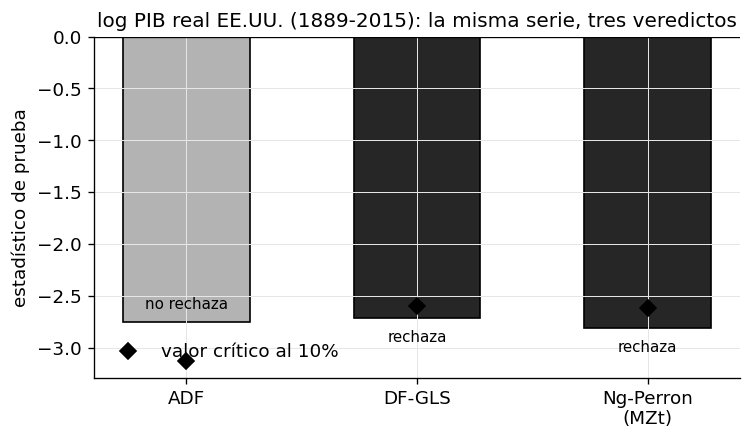

In [3]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
tests = ["ADF", "DF-GLS", "Ng-Perron\n(MZt)"]
stats = [adf_g["stat"], dfg_g["stat"], ngp_g["stat"]]
cv10 = [adf_g["crit_values"]["10%"], dfg_g["crit_values"]["10%"],
        ngp_g["crit_values"]["10%"]]
x = np.arange(3)
cols = ["0.15" if s < c else "0.7" for s, c in zip(stats, cv10)]
ax.bar(x, stats, color=cols, edgecolor="0.0", width=0.55)
ax.plot(x, cv10, "D", color="0.0", ms=7, label="valor crítico al 10%")
for xi, (s, c) in enumerate(zip(stats, cv10)):
    ax.annotate("rechaza" if s < c else "no rechaza", (xi, s),
                textcoords="offset points", xytext=(0, -14 if s < c else 8),
                ha="center", fontsize=9)
ax.axhline(0, color="0.0", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(tests)
ax.set_ylabel("estadístico de prueba")
ax.set_title("log PIB real EE.UU. (1889-2015): la misma serie, tres veredictos")
ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

**Cómo leerlo.** Los tres estadísticos se agrupan cerca de $-2.7$ — la
*estimación puntual* de la persistencia es idéntica. Lo que difiere es la vara:
como la desentendencia GLS no malgasta grados de libertad ajustando la
tendencia contra la prueba, los valores críticos al 10% de DF-GLS / Ng-Perron
($\approx -2.6$) son menos exigentes que el de ADF ($\approx -3.1$), así que el
mismísimo $-2.7$ pasa la vara GLS y no llega a la vara MCO. Esta es exactamente
la situación para la que ERS lo diseñaron: una raíz suficientemente cerca de
uno para que ADF tenga poca potencia, pero suficientemente lejos para que una
mejor prueba vea la reversión a la media.

## La brecha de potencia, hecha explícita — un Monte Carlo

¿Ese único dato es suerte, o potencia sistemáticamente mayor? Simula series
estacionarias en tendencia $y_t = 0.05\,t + u_t$,
$u_t = \phi u_{t-1}+\varepsilon_t$, y cuenta cuán seguido cada prueba rechaza la
hipótesis (falsa) de raíz unitaria al 5% cuando $\phi\to 1$. Bajo la
alternativa, *más rechazos = más potencia*.

In [4]:
def _rejection_rates(phi, T=200, n_rep=300, seed0=0):
    adf_r = dfg_r = 0
    for r in range(n_rep):
        rng = np.random.default_rng(seed0 + r)
        u = np.zeros(T)
        for t in range(1, T):
            u[t] = phi * u[t - 1] + rng.standard_normal()
        y = 0.05 * np.arange(T) + u
        adf_r += adf_test(y, regression="ct")["p_value"] < 0.05
        dfg_r += dfgls_test(y, regression="ct")["p_value"] < 0.05
    return adf_r / n_rep, dfg_r / n_rep

PHIS = [0.80, 0.85, 0.90, 0.93, 0.95, 0.97]
adf_pow, dfg_pow = [], []
for phi in PHIS:
    a, d = _rejection_rates(phi)
    adf_pow.append(a); dfg_pow.append(d)
    print(f"  phi={phi:.2f}:  potencia ADF={a:.2f}   potencia DF-GLS={d:.2f}   "
          f"ganancia={d - a:+.2f}")

  phi=0.80:  potencia ADF=1.00   potencia DF-GLS=1.00   ganancia=+0.00
  phi=0.85:  potencia ADF=0.95   potencia DF-GLS=1.00   ganancia=+0.05
  phi=0.90:  potencia ADF=0.62   potencia DF-GLS=0.85   ganancia=+0.23


  phi=0.93:  potencia ADF=0.32   potencia DF-GLS=0.54   ganancia=+0.22
  phi=0.95:  potencia ADF=0.15   potencia DF-GLS=0.30   ganancia=+0.16


  phi=0.97:  potencia ADF=0.07   potencia DF-GLS=0.12   ganancia=+0.05


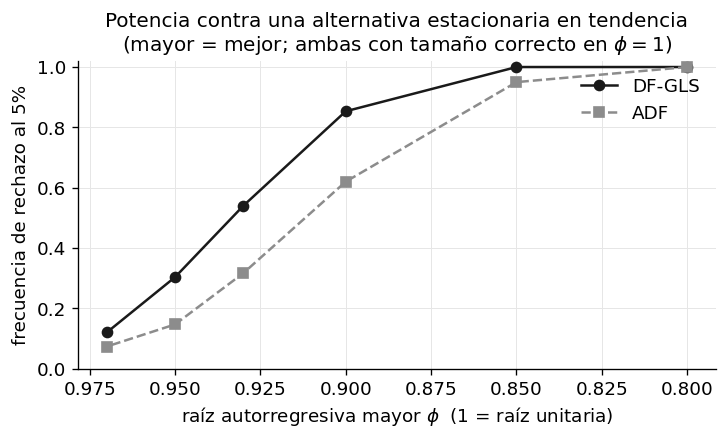

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot(PHIS, dfg_pow, "-o", color="0.10", label="DF-GLS")
ax.plot(PHIS, adf_pow, "--s", color="0.55", label="ADF")
ax.set_xlabel(r"raíz autorregresiva mayor $\phi$  (1 = raíz unitaria)")
ax.set_ylabel("frecuencia de rechazo al 5%")
ax.set_title("Potencia contra una alternativa estacionaria en tendencia\n(mayor = mejor; ambas con tamaño correcto en $\\phi=1$)")
ax.set_ylim(0, 1.02)
ax.legend(loc="upper right")
ax.invert_xaxis()  # acercándose a la raíz unitaria desde la izquierda
plt.tight_layout(); plt.show()

**El argumento de venta.** Cuando $\phi$ sube hacia $1$ — precisamente la
región donde distinguir estacionario de integrado es difícil — DF-GLS mantiene
potencia significativa mientras que la de ADF se derrumba hacia su tamaño. La
brecha vertical entre las curvas es la probabilidad de rechazo extra que compra
la desentendencia GLS, y es más ancha exactamente donde viven las series macro
reales como el producto. (En $\phi=1$ ambas pruebas rechazan solo ~5% de las
veces, confirmando que ninguna está sobredimensionada — la brecha es potencia
genuina, no una prueba más laxa.)

## Una segunda serie — la tasa de desempleo revierte a la media

La tasa de desempleo no tiene tendencia pero es muy persistente, así que es el
análogo del caso constante ($\bar c=-7$) del debate del PIB. Aquí DF-GLS *y*
ADF rechazan ambas una raíz unitaria en toda la muestra 1948-2026 — y KPSS
(cuya nula es lo opuesto, *estacionariedad*) no rechaza — un veredicto
coherente de "persistente pero con reversión a la media". Las pruebas M
coinciden.

In [6]:
print("Tasa de desempleo EE.UU., 1948-2026 (caso constante, c-bar=-7):")
print(_fmt(adf_test(unrate, regression="c"), "ADF"))
print(_fmt(dfgls_test(unrate, regression="c"), "DF-GLS"))
print(_fmt(ng_perron_test(unrate, regression="c"), "Ng-Perron"), "(MZt)")
kp = kpss_test(unrate, regression="c")
print(f"  KPSS      stat={kp['stat']:.3f}  p={kp['p_value']:.3f}  "
      f"-> {kp['decision'].upper()} (H0=estacionaria; NO rechazar = estacionaria)")
print("=> las pruebas de raíz unitaria rechazan una raíz unitaria; KPSS no rechaza"
      " estacionariedad: la tasa revierte a la media.")

Tasa de desempleo EE.UU., 1948-2026 (caso constante, c-bar=-7):
  ADF       stat=-3.817  p=0.005  rez=0  VC(10%)=-2.57  -> REJECT
  DF-GLS    stat=-2.309  p=0.026  rez=0  VC(10%)=-1.62  -> REJECT
  Ng-Perron stat=-2.301  p=0.029  rez=0  VC(10%)=-1.62  -> REJECT (MZt)
  KPSS      stat=0.348  p=0.099  -> ACCEPT (H0=estacionaria; NO rechazar = estacionaria)
=> las pruebas de raíz unitaria rechazan una raíz unitaria; KPSS no rechaza estacionariedad: la tasa revierte a la media.


## Tu turno — ¿dónde cambia la historia la potencia extra?

La brecha de potencia solo importa cuando una serie está en la zona ambigua.
Encuentra una.

**Ejercicios.** (1) *Básico*: cambia el log del PIB real por el **log de la
producción industrial** (`load_csv("okun")["indpro"]`, caso tendencia) — ahí
ambas pruebas no rechazan; ¿la raíz mayor está simplemente demasiado cerca de
uno para que *cualquier* prueba ayude? (2) *Intermedio*: reejecuta las pruebas
del PIB sobre **submuestras post-1947** de `rz2018`; a medida que la ventana se
encoge, la potencia de ADF cae más rápido que la de DF-GLS — grafica los dos
$p$-valores contra la longitud de muestra. (3) *Avanzado*: agrega un componente
MA negativo al DGP del Monte Carlo ($\varepsilon_t - 0.5\varepsilon_{t-1}$) y
compara el *tamaño* de ADF (tasa de rechazo en $\phi=1$) con el $MZ_t$ de
Ng-Perron — esta es la distorsión de tamaño que Ng & Perron (2001)
construyeron las pruebas M para corregir.

**¿Qué tan completo es esto?** `puremacro.tests.unit_root` incluye `adf_test`,
`pp_test`, `kpss_test`, `zivot_andrews_test` (quiebre endógeno), y ahora
`dfgls_test` + `ng_perron_test` (las cuatro M-estadísticas con valores críticos
de Ng-Perron 2001), compartiendo un mismo núcleo de valores críticos /
$p$-valores estilo MacKinnon — así que un flujo completo de estacionariedad
(ADF/DF-GLS confirmatorias + KPSS complementaria + Zivot-Andrews robusta a
quiebres) vive tras un solo import.